상관분석 : 두 변수 간의 선형적 관계를 평가하는 통계적 기법, 한 변수의 변화가 다른 변수와 얼마나 관련이 있는지 파악 가능함

    1) 상관계수 : 두 변수 간의 선형적 관계의 강도와 방향을 수치적으로 표현
        - r = 1 : 두 변수 간 완벽한 양의 선형 관계 (한 변수가 증가하면 다른 변수도 증가)
        - r = 0 : 두 변수 간 선형 관계 없음
        - r = -1 : 두 변수 간 완벽한 음의 선형 관계 (한 변수가 증가하면 다른 변수는 감소)
    2) 상관분석의 종류 
        [1] 피어슨 상관계수 : 가장 널리 사용되는 방법, 두 변수 간의 선형 관계를 측정
            - 조건 : 데이터가 **연속형** 이고, **정규분포**를 따른다는 가정
        [2] 스피어만 상관계수 : 순위 기반 상관계수, 두 변수 간의 비선형 관계도 측정 가능
            - 데이터를 순위로 변환 후 피어슨 상관계수를 계산
    3) 상관계수의 한계 
        [1] 인과관계와 상관관계의 혼동: 상관 관계가 있다고 하나의 변수가 다른 변수에 영향을 준다는 것은 아님
            ex) 아이스크림 판매량과 익사 사고는 상관관계가 높지만, 인과관계는 없음 
        [2] 피어슨 상관계수는 비선형 관계를 탐지하지 못한다
        [3] 결측치나 이상치의 영향을 받는다


실습 데이터 해석 

    - age: 환자의 나이
    - chol : 혈중 콜레스테롤 수치
    - thalach : 환자가 운동 중 도달한 최대 심박수
    - output: 심장병 유무 (1: 있음, 0: 없음)



In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 1. 데이터 확인 
path = 'C:/juehyeon/aice_test/materials/datasets/'
df = pd.read_csv(path + 'heart.csv')
print(df.head())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [8]:
# 2. 상관계수 계산
correlation_matrix = df.corr(method = 'pearson') # 피어슨 상관계수 사용
print(correlation_matrix)

               age       sex        cp    trtbps      chol       fbs  \
age       1.000000 -0.098447 -0.068653  0.279351  0.213678  0.121308   
sex      -0.098447  1.000000 -0.049353 -0.056769 -0.197912  0.045032   
cp       -0.068653 -0.049353  1.000000  0.047608 -0.076904  0.094444   
trtbps    0.279351 -0.056769  0.047608  1.000000  0.123174  0.177531   
chol      0.213678 -0.197912 -0.076904  0.123174  1.000000  0.013294   
fbs       0.121308  0.045032  0.094444  0.177531  0.013294  1.000000   
restecg  -0.116211 -0.058196  0.044421 -0.114103 -0.151040 -0.084189   
thalachh -0.398522 -0.044020  0.295762 -0.046698 -0.009940 -0.008567   
exng      0.096801  0.141664 -0.394280  0.067616  0.067023  0.025665   
oldpeak   0.210013  0.096093 -0.149230  0.193216  0.053952  0.005747   
slp      -0.168814 -0.030711  0.119717 -0.121475 -0.004038 -0.059894   
caa       0.276326  0.118261 -0.181053  0.101389  0.070511  0.137979   
thall     0.068001  0.210041 -0.161736  0.062210  0.098803 -0.03

[해석] 
1. age와 thalach : -0.398522의 상관계수를 가지며 음의 상관관계를 가진다. 나이가 많을수록 최대 심박수가 감소하는 경향
2. thalach와 output: 0.421741의 상관계수로 양의 상관관계를 가짐. 최대 심박수가 높을 수록 심장병 가능성이 높음

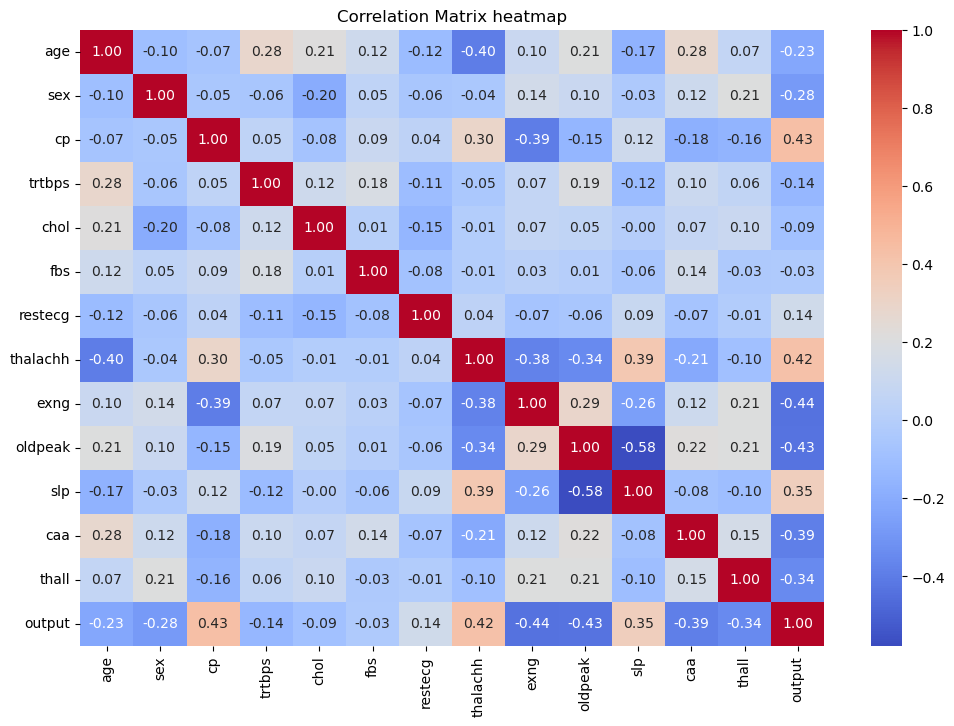

In [9]:
# 3. heatmap 시각화
plt.figure(figsize = (12,8))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = 'coolwarm', cbar = True)
plt.title('Correlation Matrix heatmap')
plt.show()

heatmap 옵션

1. annot : 상관계수의 값을 숫자로 표시할지에 대한 여부
2. fmt : 상관계수를 소수 몇 째 자리까지 표시할지
3. cmap : 그래프의 색상 파레트
4. cbar : 색상 bar 추가 여부